DATASET SHAPE
(891, 13)

COLUMN NAMES
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked', 'Title', 'Log_Fare'],
      dtype='object')

FIRST 5 ROWS
   PassengerId  Survived  Pclass  \
0            1       0.0     3.0   
1            2       1.0     1.0   
2            3       1.0     3.0   
3            4       1.0     1.0   
4            5       0.0     3.0   

                                                Name     Sex  Age  SibSp  \
0                            Braund, Mr. Owen Harris    male   22      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female   38      1   
2                             Heikkinen, Miss. Laina  female   26      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female   35      1   
4                           Allen, Mr. William Henry    male   35      0   

   Parch            Ticket     Fare Embarked Title  Log_Fare  
0      0         A/5 21171   7.2500        S  

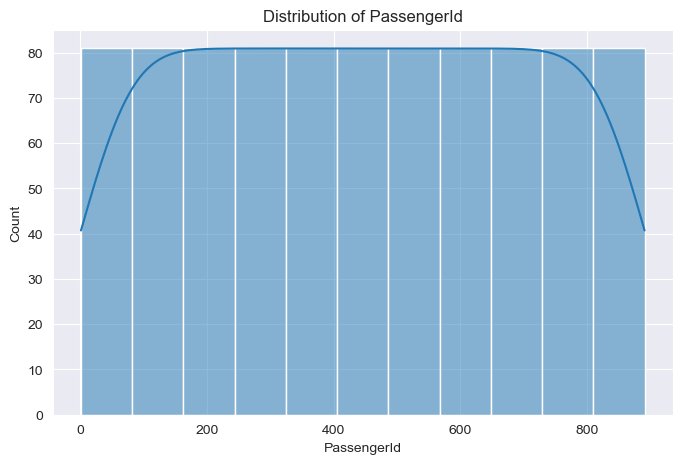

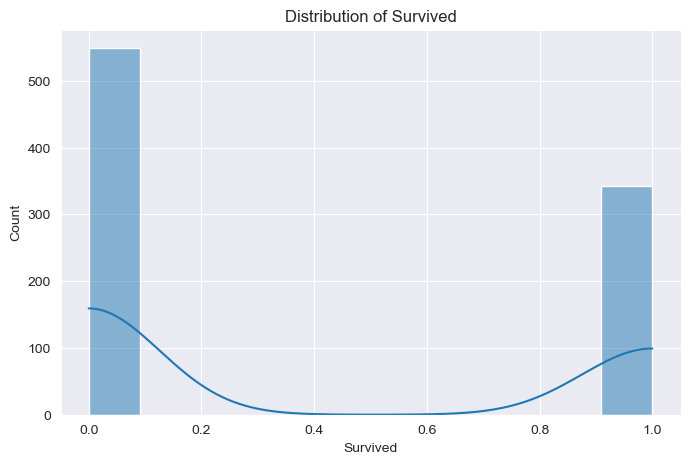

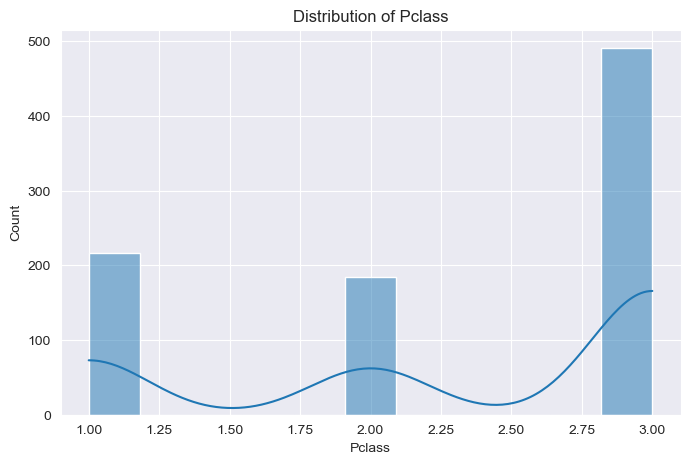

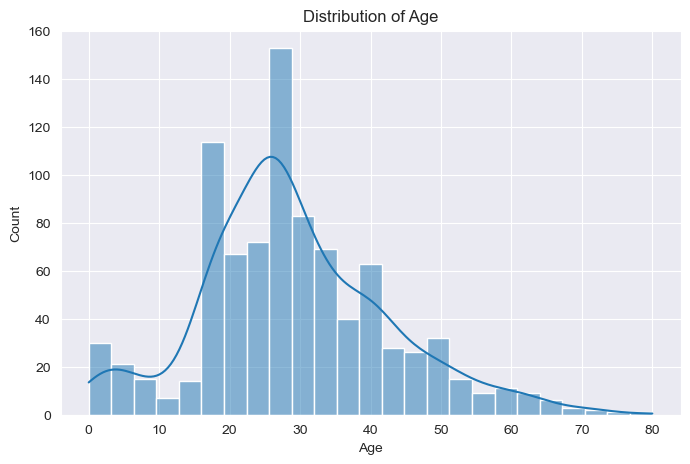

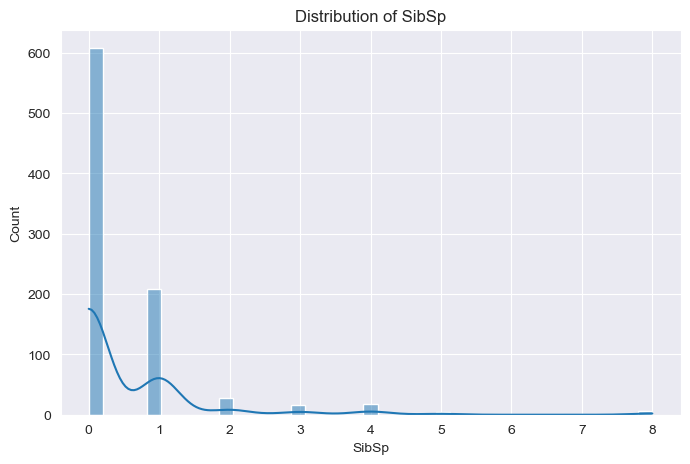

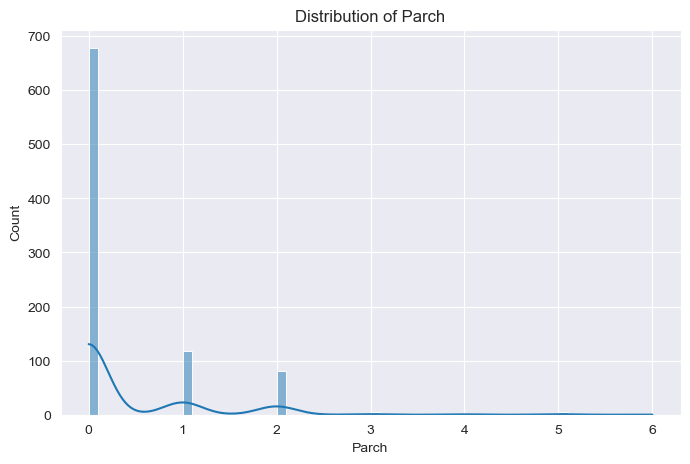

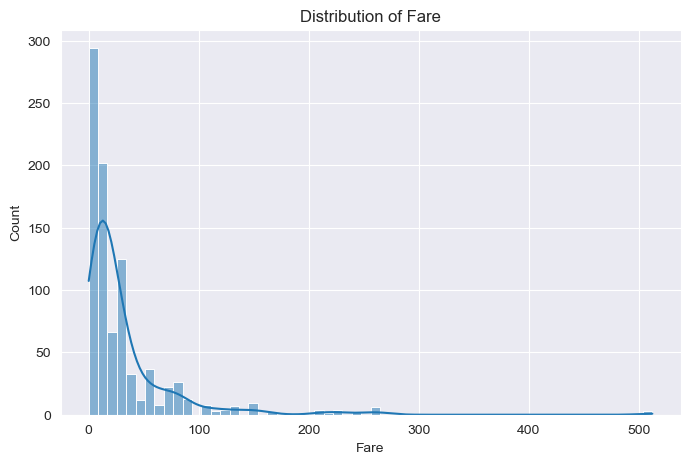

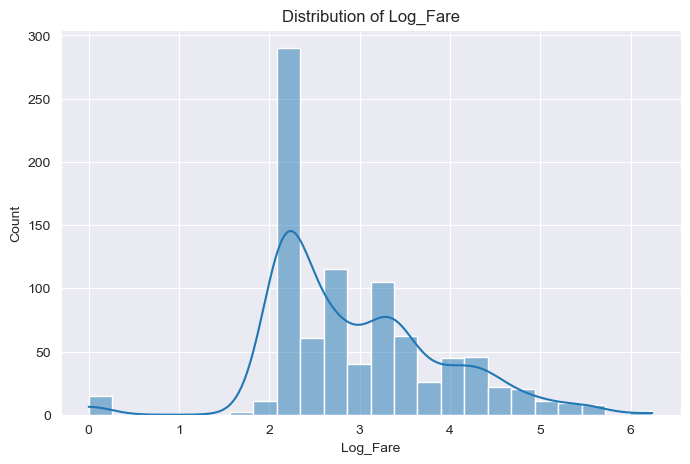

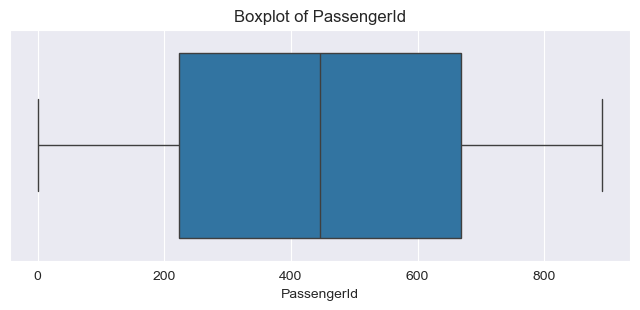

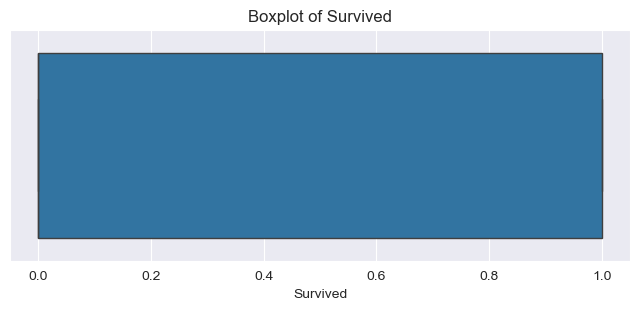

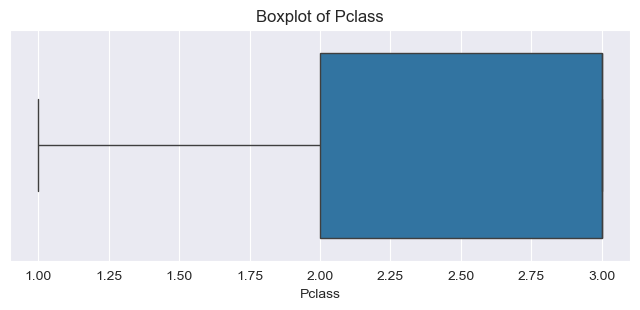

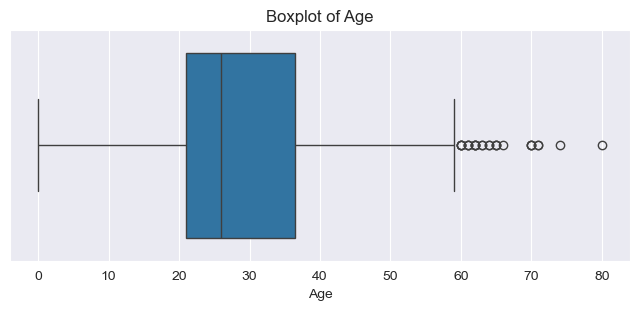

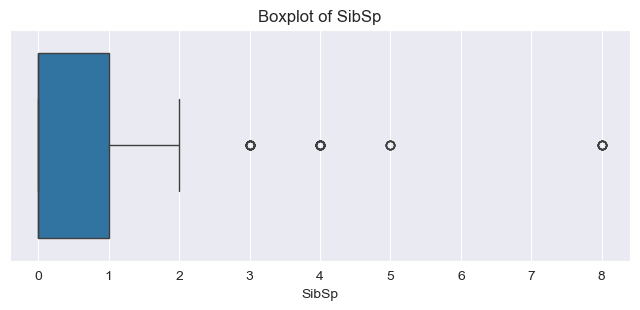

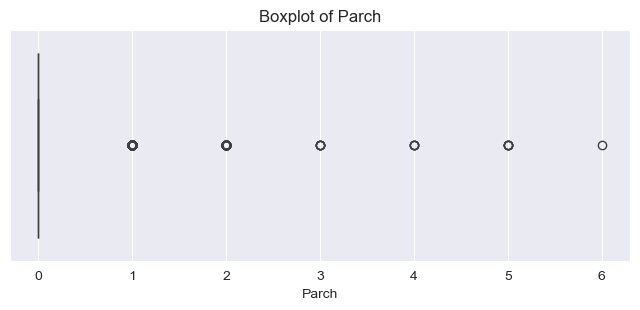

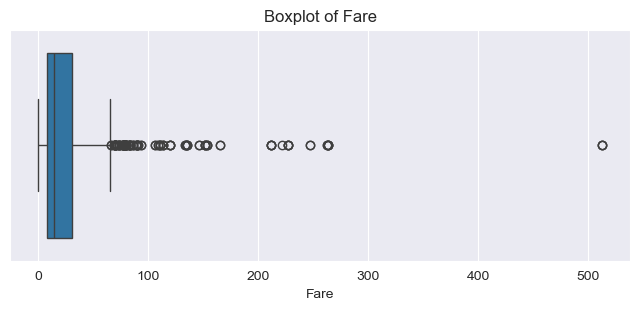

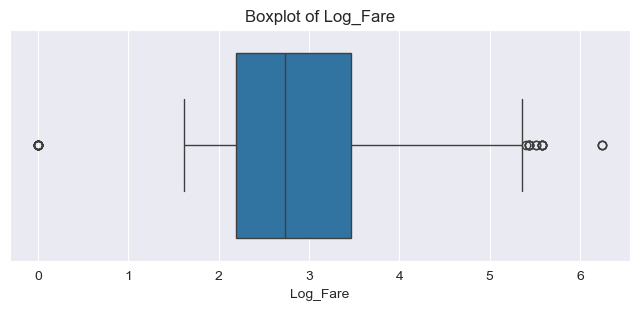


OUTLIERS
PassengerId --> 0 outliers
Survived --> 0 outliers
Pclass --> 0 outliers
Age --> 26 outliers
SibSp --> 46 outliers
Parch --> 213 outliers
Fare --> 116 outliers
Log_Fare --> 31 outliers


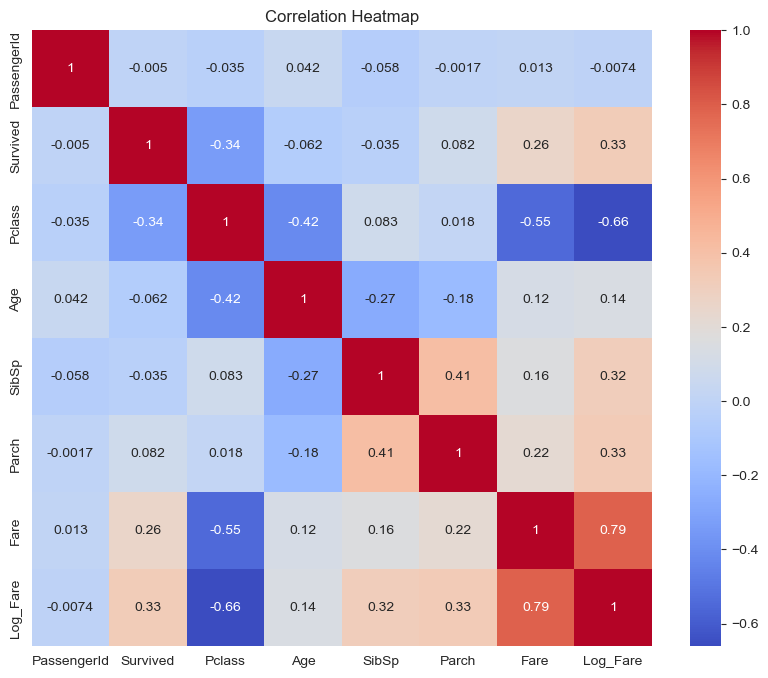

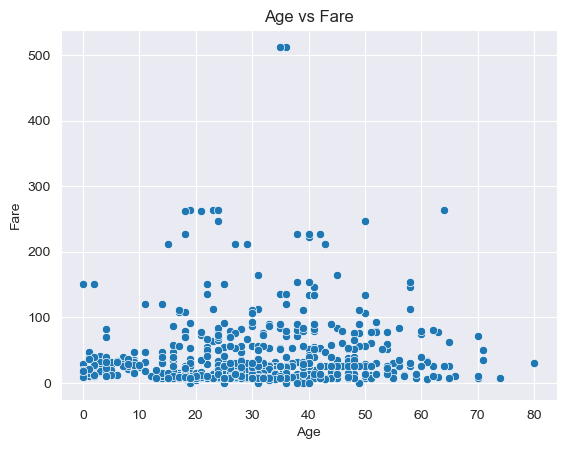

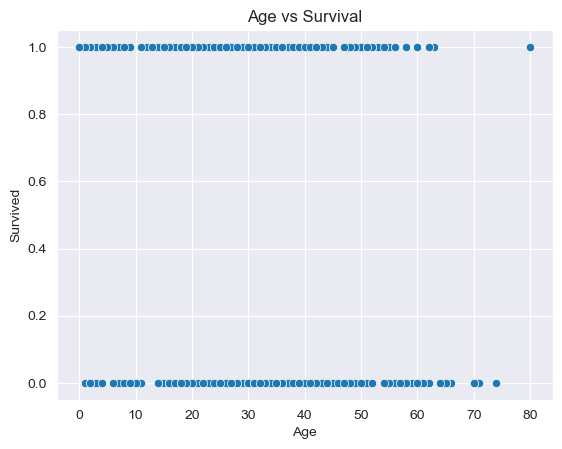


CORRELATION WITH SURVIVED
Survived       1.000000
Log_Fare       0.329862
Fare           0.257307
Parch          0.081629
PassengerId   -0.005007
SibSp         -0.035322
Age           -0.061614
Pclass        -0.338481
Name: Survived, dtype: float64


In [12]:
# ==========================================
# TITANIC STATISTICS ANALYSIS PROJECT
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------
# 1. LOAD DATA
# ------------------------------------------

df = pd.read_csv("data/titanic_cleaned.csv")

print("=" * 50)
print("DATASET SHAPE")
print("=" * 50)
print(df.shape)

print("\n" + "=" * 50)
print("COLUMN NAMES")
print("=" * 50)
print(df.columns)

print("\n" + "=" * 50)
print("FIRST 5 ROWS")
print("=" * 50)
print(df.head())


# ------------------------------------------
# 2. CHECK MISSING VALUES
# ------------------------------------------

print("\n" + "=" * 50)
print("MISSING VALUES")
print("=" * 50)
print(df.isnull().sum())


# ------------------------------------------
# 3. NUMERICAL COLUMNS
# ------------------------------------------

num_cols = df.select_dtypes(include=np.number).columns

print("\n" + "=" * 50)
print("NUMERICAL COLUMNS")
print("=" * 50)
print(list(num_cols))


# ------------------------------------------
# 4. DESCRIPTIVE STATISTICS
# ------------------------------------------

print("\n" + "=" * 50)
print("DESCRIPTIVE STATISTICS")
print("=" * 50)
print(df[num_cols].describe())


# ------------------------------------------
# 5. MEAN MEDIAN MODE
# ------------------------------------------

print("\n" + "=" * 50)
print("MEAN MEDIAN MODE")
print("=" * 50)

for col in num_cols:
    print(f"\n{col}")
    print("Mean   :", round(df[col].mean(), 3))
    print("Median :", round(df[col].median(), 3))
    print("Mode   :", df[col].mode()[0])


# ------------------------------------------
# 6. RANGE VARIANCE STD
# ------------------------------------------

print("\n" + "=" * 50)
print("RANGE VARIANCE STANDARD DEVIATION")
print("=" * 50)

for col in num_cols:
    print(f"\n{col}")
    print("Range    :", round(df[col].max() - df[col].min(), 3))
    print("Variance :", round(df[col].var(), 3))
    print("Std Dev  :", round(df[col].std(), 3))


# ------------------------------------------
# 7. SKEWNESS
# ------------------------------------------

print("\n" + "=" * 50)
print("SKEWNESS")
print("=" * 50)

for col in num_cols:
    print(f"{col} : {round(df[col].skew(),3)}")


# ------------------------------------------
# 8. MEAN VS MEDIAN ANALYSIS
# ------------------------------------------

print("\n" + "=" * 50)
print("MEAN VS MEDIAN")
print("=" * 50)

for col in num_cols:

    mean = df[col].mean()
    median = df[col].median()

    if mean > median:
        skew = "Positive Skew"

    elif mean < median:
        skew = "Negative Skew"

    else:
        skew = "Approximately Symmetric"

    print(f"{col} --> {skew}")


# ------------------------------------------
# 9. HISTOGRAMS
# ------------------------------------------

for col in num_cols:

    plt.figure(figsize=(8,5))

    sns.histplot(
        df[col],
        kde=True
    )

    plt.title(f"Distribution of {col}")

    plt.show()


# ------------------------------------------
# 10. BOXPLOTS
# ------------------------------------------

for col in num_cols:

    plt.figure(figsize=(8,3))

    sns.boxplot(
        x=df[col]
    )

    plt.title(f"Boxplot of {col}")

    plt.show()


# ------------------------------------------
# 11. OUTLIER DETECTION (IQR METHOD)
# ------------------------------------------

print("\n" + "=" * 50)
print("OUTLIERS")
print("=" * 50)

for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
        ]

    print(f"{col} --> {len(outliers)} outliers")


# ------------------------------------------
# 12. CORRELATION MATRIX
# ------------------------------------------

corr = df[num_cols].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()


# ------------------------------------------
# 13. SCATTER PLOTS
# ------------------------------------------

sns.scatterplot(
    data=df,
    x="Age",
    y="Fare"
)

plt.title("Age vs Fare")

plt.show()


sns.scatterplot(
    data=df,
    x="Age",
    y="Survived"
)

plt.title("Age vs Survival")

plt.show()


# ------------------------------------------
# 14. CORRELATION WITH SURVIVAL
# ------------------------------------------

print("\n" + "=" * 50)
print("CORRELATION WITH SURVIVED")
print("=" * 50)

print(
    corr["Survived"]
    .sort_values(ascending=False)
)

# Insights

#### 1. Dataset Quality

* The dataset contains **891 rows and 13 columns**.
* There are **no missing values**, indicating the dataset was successfully cleaned before analysis.

---

#### 2. Survival Rate

* Mean of `Survived` = **0.384**
* This means approximately **38.4% passengers survived** and **61.6% did not survive**.

---

#### 3. Passenger Age Analysis

* Mean Age = **29.12**
* Median Age = **26**
* Mean > Median, indicating a **slight positive skew**.
* Most passengers were relatively young adults.
* Age ranges from **0 to 80 years**.

---

#### 4. Fare Distribution

* Mean Fare = **32.20**
* Median Fare = **14.45**
* Mean is much larger than Median.
* Fare has a skewness of **4.787**, which is extremely high.
* This shows that a small number of passengers paid very expensive fares while most passengers paid relatively low fares.

---

#### 5. Effect of Log Transformation

* Original Fare skewness = **4.787**
* Log_Fare skewness = **0.395**
* Log transformation significantly reduced skewness.
* Therefore, `Log_Fare` is closer to a normal distribution and is better suited for many ML algorithms.

---

#### 6. Passenger Class Distribution

* Median Pclass = **3**
* Mean Pclass = **2.31**
* Negative skewness (-0.631) suggests that most passengers belonged to **3rd class**.

---

#### 7. Family Size Features

##### SibSp

* Skewness = **3.695**
* Most passengers traveled without siblings/spouses.

##### Parch

* Skewness = **2.749**
* Most passengers traveled without parents/children.

Both features are heavily concentrated around zero.

---

#### 8. Outlier Analysis

Number of detected outliers:

| Feature  | Outliers |
| -------- | -------: |
| Age      |       26 |
| SibSp    |       46 |
| Parch    |      213 |
| Fare     |      116 |
| Log_Fare |       31 |

Observations:

* `Parch` contains the highest number of outliers.
* `Fare` contains many extreme values.
* Log transformation reduced Fare outliers from **116 to 31**.

---

#### 9. Variability Analysis

Highest standard deviations:

| Feature | Std Dev |
| ------- | ------: |
| Fare    |   49.69 |
| Age     |   13.50 |
| SibSp   |    1.10 |

Observations:

* Fare shows the greatest variability.
* Ticket prices differed significantly between passengers.

---

#### 10. Correlation with Survival

Correlation with `Survived`:

| Feature  | Correlation |
| -------- | ----------: |
| Log_Fare |       0.330 |
| Fare     |       0.257 |
| Parch    |       0.082 |
| Age      |      -0.062 |
| SibSp    |      -0.035 |
| Pclass   |      -0.338 |

Key findings:

* **Pclass** has the strongest relationship with survival.
* Higher class number (3rd class) corresponds to lower survival probability.
* Higher fares are associated with higher survival rates.
* Age has very weak correlation with survival.